In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore") 

In [2]:
np.random.seed(42)
n = 300

area = np.random.normal(1800, 500, n).clip(600, 4000)
bedrooms = np.clip(np.round(area / 600 + np.random.normal(0, 0.5, n)), 1, 6)
age = np.random.uniform(0, 50, n)
distance = np.random.uniform(1, 40, n)
school_rating = np.random.uniform(3, 10, n)
crime_index = np.random.uniform(10, 90, n)
price_per_sqft = np.random.normal(150, 30, n)

days_on_market = (90 + 1.5 * (price_per_sqft - 150) + 2.5 * distance + 1.2 * age
                  - 8 * school_rating + 0.6 * crime_index + np.random.normal(0, 30, n))
days_on_market = np.clip(days_on_market, 5, 400)

df = pd.DataFrame({
    'area_sqft': area, 'bedrooms': bedrooms, 'age_years': age,
    'distance_km': distance, 'school_rating': school_rating,
    'crime_index': crime_index, 'price_per_sqft': price_per_sqft
})
df['unsold'] = (days_on_market > 180).astype(int)  

print(df.shape)
print(df['unsold'].value_counts())
df.head() 

(300, 8)
unsold
0    211
1     89
Name: count, dtype: int64


,area_sqft,bedrooms,age_years,distance_km,school_rating,crime_index,price_per_sqft,unsold
0,2048.357077,3.0,11.462570,15.988739,6.117137,16.473543,136.018905,0
1,1730.867849,3.0,36.112628,27.506244,6.603721,42.238414,102.158908,0
2,2123.844269,4.0,36.001827,9.511902,5.514634,23.881961,165.408003,0
3,2561.514928,5.0,32.057382,38.048486,7.150656,65.596087,134.018975,1
4,1682.923313,3.0,34.697422,31.667456,4.144667,37.687978,114.902495,0


In [3]:
features = ['area_sqft', 'bedrooms', 'age_years', 'distance_km',
            'school_rating', 'crime_index', 'price_per_sqft']

scaled_data = StandardScaler().fit_transform(df[features])

principal = PCA(n_components=3)
x = principal.fit_transform(scaled_data)
print("Transformed shape:", x.shape) 

Transformed shape: (300, 3)


In [4]:
print("Explained variance ratio:", principal.explained_variance_ratio_)
print("Total variance explained:", principal.explained_variance_ratio_.sum())

loadings = pd.DataFrame(principal.components_.T,
                        columns=['PC1', 'PC2', 'PC3'], index=features)
print("\nLoadings:")
print(loadings.round(3)) 

Explained variance ratio: [0.26311016 0.16306495 0.14579057]
Total variance explained: 0.5719656816542383

Loadings:
                  PC1    PC2    PC3
area_sqft       0.692 -0.069  0.052
bedrooms        0.697 -0.068 -0.069
age_years       0.008  0.610 -0.034
distance_km     0.168  0.457 -0.083
school_rating  -0.009 -0.586 -0.403
crime_index    -0.082 -0.058 -0.413
price_per_sqft -0.014 -0.252  0.807


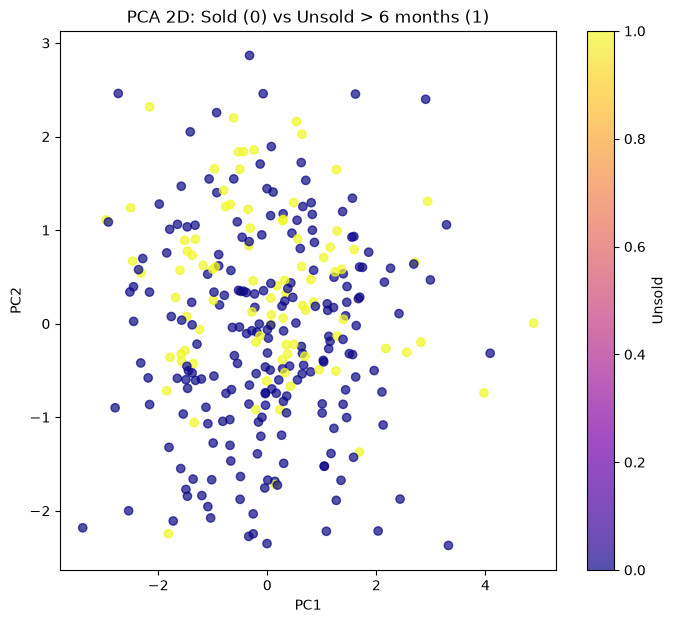

In [5]:
plt.figure(figsize=(8, 7))
plt.scatter(x[:, 0], x[:, 1], c=df['unsold'], cmap='plasma', alpha=0.7)
plt.title('PCA 2D: Sold (0) vs Unsold > 6 months (1)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Unsold')
plt.show() 

In [6]:
comparison = df.groupby('unsold')[features].mean().round(2)
comparison.index = ['Sold (<= 6 months)', 'Unsold (> 6 months)']
comparison 

,area_sqft,bedrooms,age_years,distance_km,school_rating,crime_index,price_per_sqft
Sold (<= 6 months),1803.63,3.01,23.01,18.65,6.83,46.95,140.66
Unsold (> 6 months),1788.00,2.92,28.06,27.11,5.84,55.61,174.05
